In [2]:
pip install pysid

Note: you may need to restart the kernel to use updated packages.


In [3]:

# IDENTIFICACIÓN DE SISTEMAS PARAMÉTRICOS

# OBJETIVO:
# Implementar técnicas de identificación paramétrica
# evaluando diferentes estructuras y órdenes de modelos
# para representar un sistema dinámico a partir de datos
# experimentales de entrada y salida.

# ESTRUCTURAS A EVALUAR:
# 1. ARX
# 2. ARMAX
# 3. OE
# 4. BJ

# ============================================================
# LIBRERÍAS NECESARIAS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import dlti, dlsim
from pysid import arx, armax, bj, oe



In [4]:
# ============================================================
# CARGA DE DATOS

# Se leen los datos experimentales almacenados en un CSV
data = pd.read_csv("D5.csv")
data.head() # Muestra las primeras filas del DataFrame para verificar la carga de datos


,t,u,y,uv,yv
0,0.00,1,0.000000,2.5,0.000000
1,0.01,1,0.214428,2.5,0.243912
2,0.02,1,0.885232,2.5,0.943198
3,0.03,1,0.072755,2.5,0.158252
4,0.04,1,0.672054,2.5,0.784173


In [5]:
# Vectores
t = np.array(data.t) # Tiempo
u = np.array(data.u) # Entrada
y = np.array(data.y) # Salida
uv = np.array(data.uv) # Entrada de validación
yv = np.array(data.yv) # Salida de validación


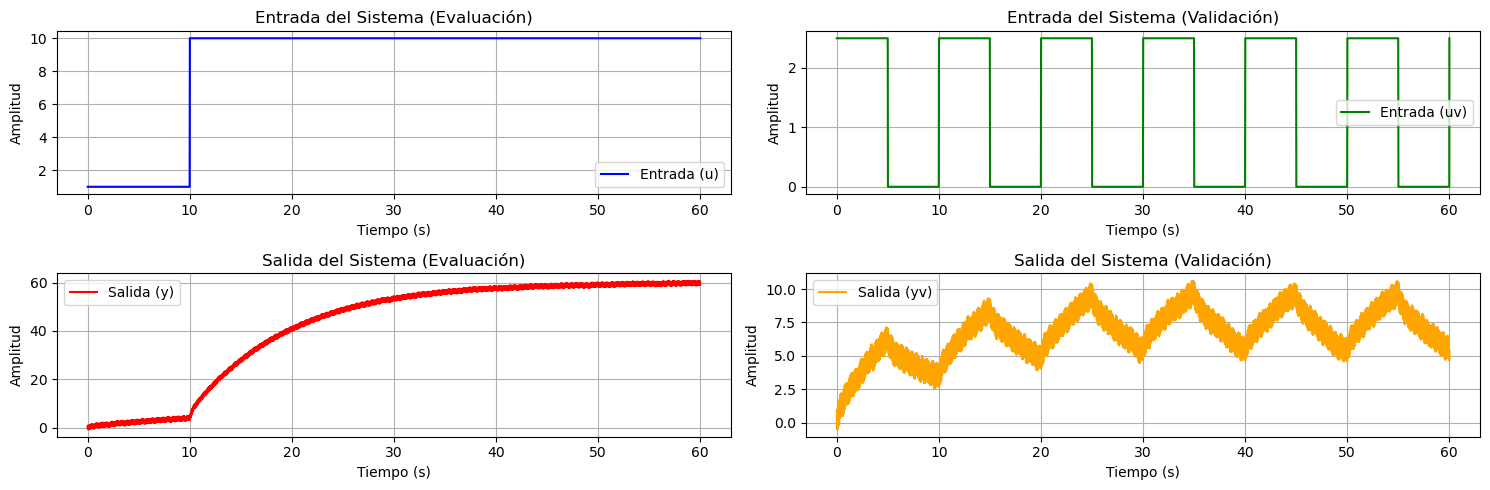

In [6]:
# Visualización de los datos

plt.figure(figsize=(15, 5))

# Entrada evalución
plt.subplot(2, 2, 1)
plt.plot(t, u, label='Entrada (u)', color='blue')
plt.title('Entrada del Sistema (Evaluación)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid()  
plt.legend()

# Entrada de validación
plt.subplot(2, 2, 2)
plt.plot(t, uv, label='Entrada (uv)', color='green')
plt.title('Entrada del Sistema (Validación)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid()
plt.legend()

# Salida evaluación
plt.subplot(2, 2, 3)
plt.plot(t, y, label='Salida (y)', color='red')
plt.title('Salida del Sistema (Evaluación)')
plt.xlabel('Tiempo (s)')        
plt.ylabel('Amplitud')
plt.grid()
plt.legend()

# Salida validación
plt.subplot(2, 2, 4)
plt.plot(t, yv, label='Salida (yv)', color='orange')
plt.title('Salida del Sistema (Validación)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# Rizado es el ruido presente en la señal de salida, 
# que puede ser causado por perturbaciones externas, ruido de medición o variaciones inherentes al sistema. Es importante analizar el rizado para entender la calidad de los datos y su impacto en la identificación del modelo.
# Para modelarlo debemos caracterizarlo con la transformada rapida de fourier para ver el valor de la frecuencia del rizado y así poder modelarlo con un filtro de Butterworth o similar.

CARACTERIZACIÓN

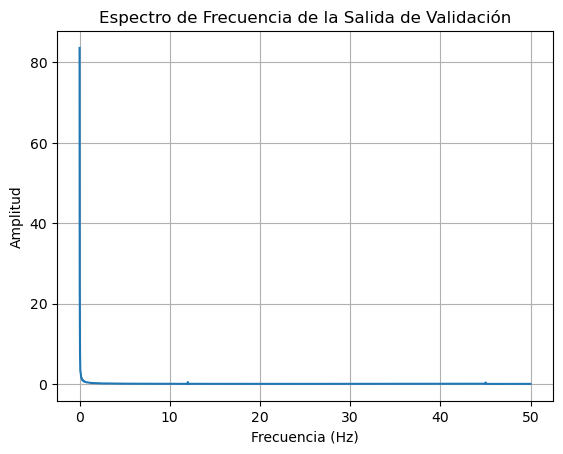

In [7]:
N = len(y)  # Número de muestras
Ts = np.mean(np.diff(t))  # Periodo de muestreo

yf = fft(y)  # Transformada rápida de Fourier  
xf = fftfreq(N, Ts)[:N//2] # Frecuencias correspondientes

plt.plot(xf, 2.0/N * np.abs(yf[0:N//2]))
plt.title('Espectro de Frecuencia de la Salida de Validación')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')
plt.grid()

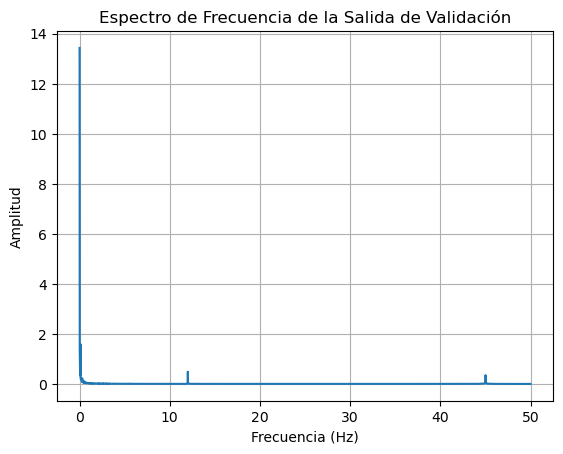

In [8]:
N = len(yv)  # Número de muestras

yf = fft(yv)  # Transformada rápida de Fourier  
xf = fftfreq(N, Ts)[:N//2] # Frecuencias correspondientes

plt.plot(xf, 2.0/N * np.abs(yf[0:N//2]))
plt.title('Espectro de Frecuencia de la Salida de Validación')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')
plt.grid()

#Muestra la distribución de frecuencias de una señal para identificar el rizado


In [9]:
# Sintaxis para utilizar las estructuras segun la librería

# AR : ar(na, y)
# ARX : arx(na, nb, nk, u, y)
# ARMA : arma(na, nc, y)
# ARMAX : armax(na, nb, nc, nk, u, y)
# OE : oe(nb, nc, nk, y, u)
# BJ : bj(nb, nc, nd, nf, nk, u, y)

TEST CON ESTRUCTURA OE

c:\Users\MARIANA\anaconda3\envs\biosignals\lib\site-packages\pysid\identification\solvers.py:42: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  phi = concatenate((toeplitz(-y[L-1:Ny-1], -y[L-na:L][::-1]), toeplitz(u[L-nk:Nu-nk], u[L-nk-nb:L-nk+1][::-1])), axis=1)


[ 0.          0.21962326 -0.21398439]
[ 1.         -1.09528798  0.09622768]


c:\Users\MARIANA\anaconda3\envs\biosignals\lib\site-packages\scipy\signal\_ltisys.py:599: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)


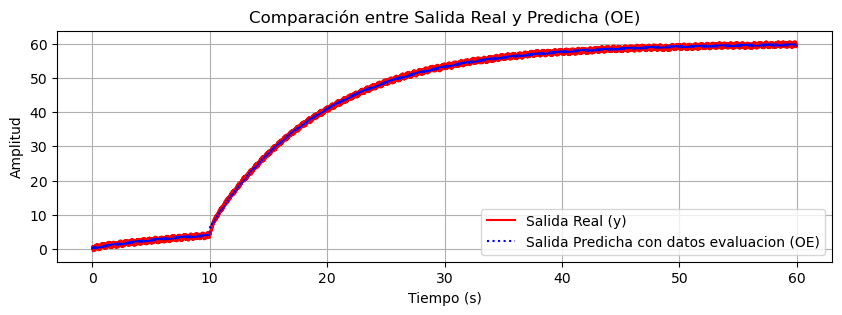

In [10]:
# Cargar modelo

nb = 1
nf = 2
nk = 1
model = oe(nb, nf, nk, u, y)

B = model.B[0,0]
F = model.F[0,0]

print(B)
print(F)

# Creacion del sistema
system = dlti(B, F, dt=Ts)

# Crear señal predichaa usando el modelo
t_out, y_tf = dlsim(system, u) # y de la funcion de transferencia con la entrada u
y_tf = y_tf.flatten()  # Aplanar el resultado para facilitar la comparación

error = 0.2*np.sin(2*np.pi*12*t)

y_sim_oe = y_tf + error

# comparacion real vs predicha

plt.figure(figsize=(10, 3))
plt.plot(t, y, label='Salida Real (y)', color='red')
plt.plot(t_out, y_sim_oe, label='Salida Predicha con datos evaluacion (OE)', color='blue', linestyle=':')
plt.title('Comparación entre Salida Real y Predicha (OE)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid()
plt.legend()
plt.show()



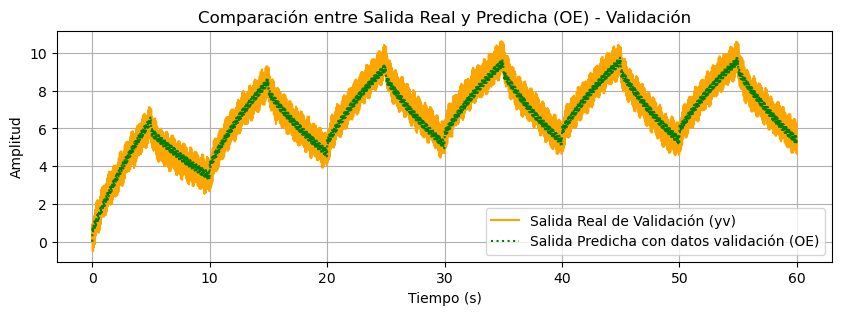

In [11]:
# Revisando con datos de validación

t_out_val, y_tf_val = dlsim(system, uv) # y de la funcion de transferencia con la entrada uv
y_tf_val = y_tf_val.flatten()  # Aplanar el resultado para facilitar la comparación
error_val = 0.2*np.sin(2*np.pi*12*t)
y_sim_oe_val = y_tf_val + error_val

plt.figure(figsize=(10, 3))
plt.plot(t, yv, label='Salida Real de Validación (yv)', color='orange')
plt.plot(t_out_val, y_sim_oe_val, label='Salida Predicha con datos validación (OE)', color='green', linestyle=':')
plt.title('Comparación entre Salida Real y Predicha (OE) - Validación')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid()
plt.legend()
plt.show()


TEST CON ESTRUCTURA ARMAX

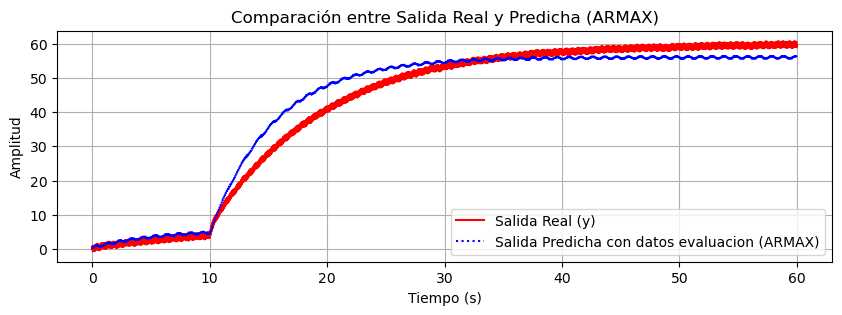

In [12]:
model = armax(2, 1, 2, 1, u, y)

B = model.B[0,0]
A = model.A[0,0]
C = model.C[0,0]

sistem_1 = dlti(B, A, dt=Ts) # Funcion de transferencia del modelo ARMAX b/a
sistem_2 = dlti(C, A, dt=Ts) # Funcion de transferencia del modelo de error c/a

# Simular salida estimada

t_out, y_signal = dlsim(sistem_1, u) # y de la funcion de transferencia con la entrada u
t_out, y_error = dlsim(sistem_2, error) # y del modelo de error con la entrada del error

y_sigal = y_signal.flatten() + y_error.flatten()
y_error = y_error.flatten()

y_sim_armax = y_sigal + error   

plt.figure(figsize=(10, 3))
plt.plot(t, y, label='Salida Real (y)', color='red')
plt.plot(t_out, y_sim_armax, label='Salida Predicha con datos evaluacion (ARMAX)', color='blue', linestyle=':')
plt.title('Comparación entre Salida Real y Predicha (ARMAX)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid()
plt.legend()
plt.show()


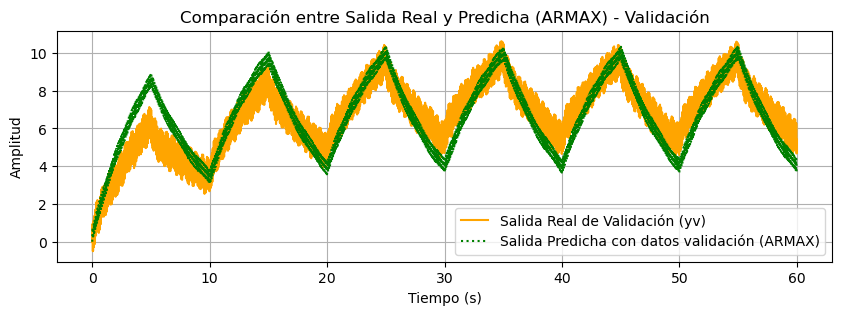

In [14]:
# Revisando con datos de validación

t_out_val, y_signal_val = dlsim(sistem_1, uv) # y de la funcion de transferencia con la entrada uv
t_out_val, y_error_val = dlsim(sistem_2, error_val) # y del modelo de error con la entrada del error

y_sigal_val = y_signal_val.flatten() + y_error_val.flatten()
y_error_val = y_error_val.flatten()

y_sim_armax_val = y_sigal_val + error_val

plt.figure(figsize=(10, 3))
plt.plot(t, yv, label='Salida Real de Validación (yv)', color='orange')
plt.plot(t_out_val, y_sim_armax_val, label='Salida Predicha con datos validación (ARMAX)', color='green', linestyle=':')
plt.title('Comparación entre Salida Real y Predicha (ARMAX) - Validación')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid()
plt.legend()
plt.show()
